# Task 4 — Proxy Target Variable Engineering

**Goal:** Since the dataset has no default label, we construct one from behavioural data using RFM analysis and K-Means clustering.

**Steps:**
1. Load and clean data
2. Calculate RFM metrics per CustomerId
3. Scale RFM features
4. Cluster customers into 3 groups with K-Means
5. Identify the high-risk cluster
6. Assign `is_high_risk` label
7. Integrate into the processed dataset

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

---
## 1. Load and Clean Data

In [2]:
df = pd.read_csv('../data/raw/data.csv', parse_dates=['TransactionStartTime'])
print(f'Raw shape: {df.shape}')

# Drop duplicate transactions, take absolute Amount
df = df.drop_duplicates(subset=['TransactionId'])
df['Amount'] = df['Amount'].abs()
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'], utc=True, errors='coerce')
df = df.dropna(subset=['TransactionStartTime', 'CustomerId', 'Amount'])

print(f'Clean shape: {df.shape}')
print(f'Unique customers: {df.CustomerId.nunique():,}')
df[['CustomerId', 'AccountId', 'Amount', 'TransactionStartTime']].head()

Raw shape: (95662, 16)
Clean shape: (95662, 16)
Unique customers: 3,742


,CustomerId,AccountId,Amount,TransactionStartTime
0,CustomerId_4406,AccountId_3957,1000.0,2018-11-15 02:18:49+00:00
1,CustomerId_4406,AccountId_4841,20.0,2018-11-15 02:19:08+00:00
2,CustomerId_4683,AccountId_4229,500.0,2018-11-15 02:44:21+00:00
3,CustomerId_988,AccountId_648,20000.0,2018-11-15 03:32:55+00:00
4,CustomerId_988,AccountId_4841,644.0,2018-11-15 03:34:21+00:00


---
## 2. Calculate RFM Metrics per CustomerId

- **Recency**: days since last transaction (low = recently active = good)
- **Frequency**: total transaction count (high = engaged = good)
- **Monetary**: total spend (high = valuable = good)

We use a fixed snapshot date (max date + 1 day) so Recency is reproducible.

In [3]:
snapshot_date = df['TransactionStartTime'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = df.groupby('CustomerId').agg(
    Recency  =('TransactionStartTime', lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionId', 'count'),
    Monetary =('Amount', 'sum'),
).reset_index()

print(f'RFM shape: {rfm.shape}')
rfm.describe().T

Snapshot date: 2019-02-14


RFM shape: (3742, 4)


,count,mean,std,min,25%,50%,75%,max
Recency,3742.0,31.461251,2.711893e+01,1.0,6.0,25.0,54.0,91.0
Frequency,3742.0,25.564404,9.692960e+01,1.0,2.0,7.0,20.0,4091.0
Monetary,3742.0,251991.140166,2.715529e+06,50.0,6450.0,32000.0,102000.0,104900000.0


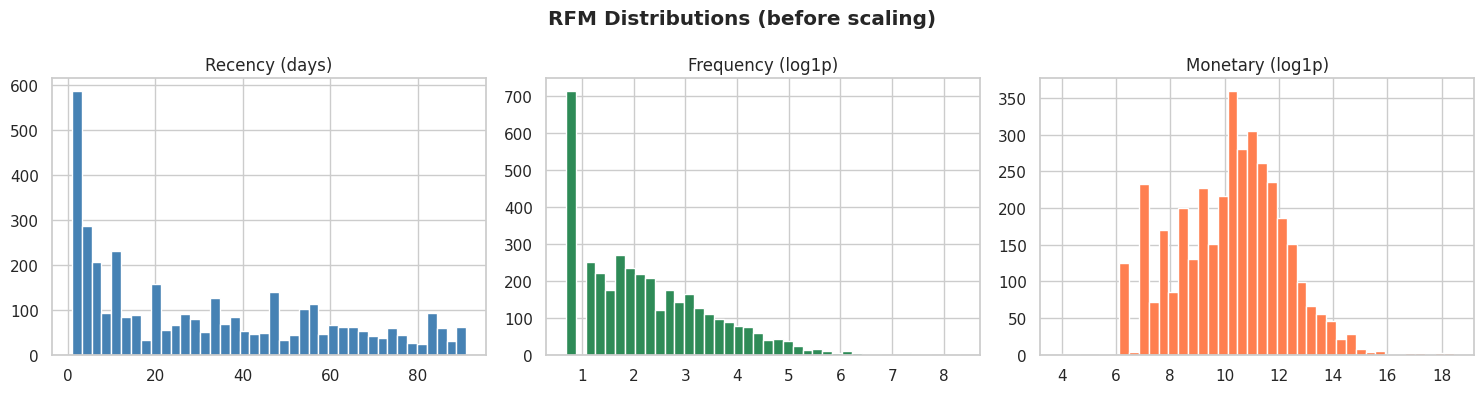

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Distributions (before scaling)', fontweight='bold')

axes[0].hist(rfm['Recency'],             bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days)')
axes[1].hist(np.log1p(rfm['Frequency']), bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency (log1p)')
axes[2].hist(np.log1p(rfm['Monetary']),  bins=40, color='coral',    edgecolor='white')
axes[2].set_title('Monetary (log1p)')
plt.tight_layout()
plt.show()

---
## 3. Scale RFM Features

K-Means uses Euclidean distance, so unscaled features with large ranges (Monetary in UGX) would dominate the clusters. `StandardScaler` brings all three features to mean=0, std=1.

In [5]:
scaler  = StandardScaler()
rfm_cols = ['Recency', 'Frequency', 'Monetary']
X_scaled = scaler.fit_transform(rfm[rfm_cols])

print('After scaling — mean (should be ~0):', X_scaled.mean(axis=0).round(3))
print('After scaling — std  (should be ~1):', X_scaled.std(axis=0).round(3))

After scaling — mean (should be ~0): [ 0. -0. -0.]
After scaling — std  (should be ~1): [1. 1. 1.]


---
## 4. Choose Number of Clusters with the Elbow Method

Plot inertia (within-cluster sum of squares) for k=2..8 to confirm k=3 is appropriate.

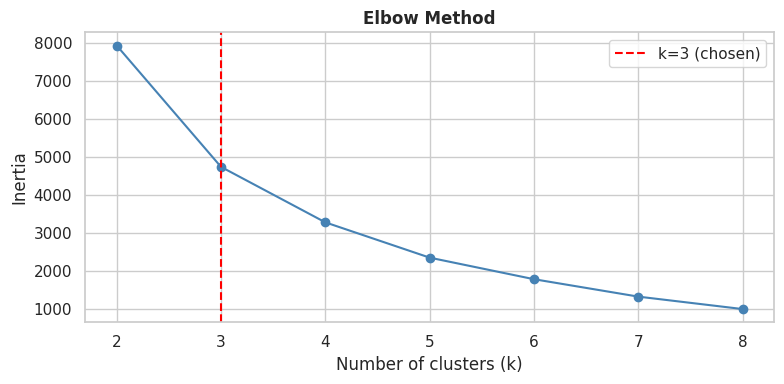

In [6]:
inertias = []
k_range  = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.axvline(x=3, color='red', linestyle='--', label='k=3 (chosen)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Fit K-Means with k=3

In [7]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

print('Customers per cluster:')
print(rfm['cluster'].value_counts().sort_index().to_string())

Customers per cluster:
cluster
0    1426
1    2312
2       4


In [8]:
# Profile each cluster
profiles = rfm.groupby('cluster')[rfm_cols].mean().round(1)
profiles['count'] = rfm.groupby('cluster').size()
print('Cluster profiles (raw mean values):')
print(profiles.to_string())

Cluster profiles (raw mean values):
         Recency  Frequency    Monetary  count
cluster                                       
0           61.9        7.7     89323.8   1426
1           12.7       34.7    223213.1   2312
2           23.2     1104.5  74876587.0      4


---
## 6. Identify the High-Risk Cluster

High-risk = **high Recency** (inactive) + **low Frequency** (rare) + **low Monetary** (low spend).

We score each cluster by ranking along all three dimensions and pick the one with the highest combined risk score.

In [9]:
profiles['risk_score'] = (
    profiles['Recency'].rank(ascending=True)      # high Recency  → high rank = risky
    + profiles['Frequency'].rank(ascending=False)  # low Frequency → high rank = risky
    + profiles['Monetary'].rank(ascending=False)   # low Monetary  → high rank = risky
)

print('Risk scores per cluster:')
print(profiles[['Recency','Frequency','Monetary','risk_score']].to_string())

high_risk_cluster = int(profiles['risk_score'].idxmax())
print(f'\nHigh-risk cluster: {high_risk_cluster}')

Risk scores per cluster:
         Recency  Frequency    Monetary  risk_score
cluster                                            
0           61.9        7.7     89323.8         9.0
1           12.7       34.7    223213.1         5.0
2           23.2     1104.5  74876587.0         4.0

High-risk cluster: 0


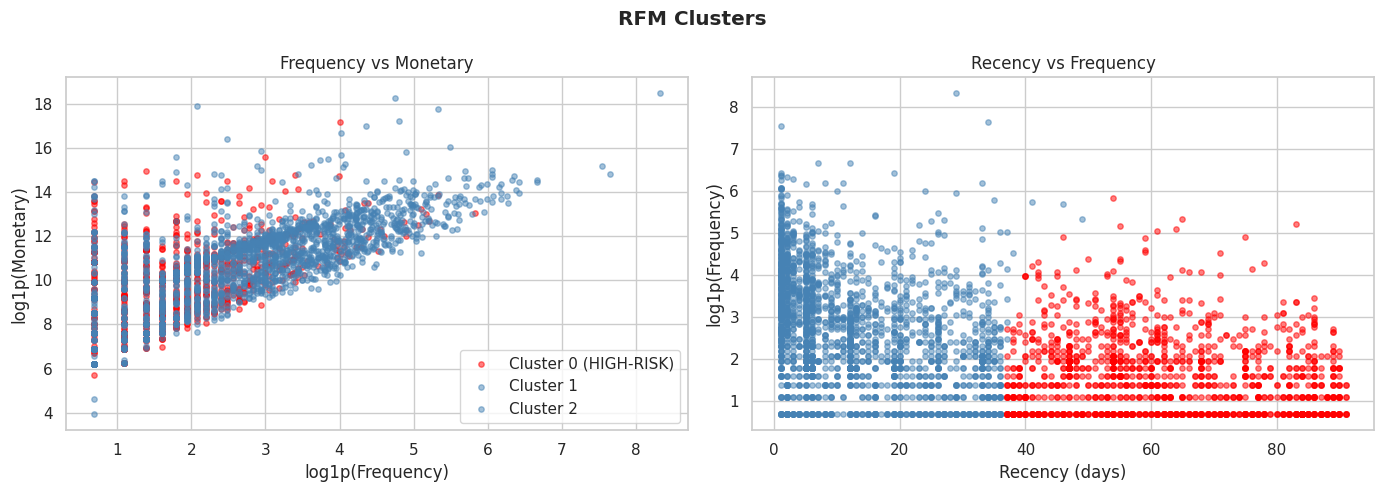

In [10]:
# Visualise the clusters: Frequency vs Monetary, coloured by Recency
colors = {c: ('red' if c == high_risk_cluster else 'steelblue') for c in rfm['cluster'].unique()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RFM Clusters', fontweight='bold')

for cluster_id, group in rfm.groupby('cluster'):
    label = f'Cluster {cluster_id} (HIGH-RISK)' if cluster_id == high_risk_cluster else f'Cluster {cluster_id}'
    axes[0].scatter(np.log1p(group['Frequency']), np.log1p(group['Monetary']),
                   c=colors[cluster_id], alpha=0.5, s=15, label=label)

axes[0].set_xlabel('log1p(Frequency)')
axes[0].set_ylabel('log1p(Monetary)')
axes[0].set_title('Frequency vs Monetary')
axes[0].legend()

for cluster_id, group in rfm.groupby('cluster'):
    axes[1].scatter(group['Recency'], np.log1p(group['Frequency']),
                   c=colors[cluster_id], alpha=0.5, s=15)

axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('log1p(Frequency)')
axes[1].set_title('Recency vs Frequency')

plt.tight_layout()
plt.show()

---
## 7. Assign `is_high_risk` Label

In [11]:
rfm['is_high_risk'] = (rfm['cluster'] == high_risk_cluster).astype(int)

print('is_high_risk distribution:')
print(rfm['is_high_risk'].value_counts().to_string())
print(f'High-risk rate: {rfm.is_high_risk.mean()*100:.1f}%')

# Confirm cluster profiles match expectation
print()
print('Mean RFM by label:')
print(rfm.groupby('is_high_risk')[rfm_cols].mean().round(1).to_string())

is_high_risk distribution:
is_high_risk
0    2316
1    1426
High-risk rate: 38.1%

Mean RFM by label:
              Recency  Frequency  Monetary
is_high_risk                              
0                12.7       36.6  352148.1
1                61.9        7.7   89323.8


---
## 8. Integrate `is_high_risk` into the Processed Dataset

The feature matrix is aggregated at the `AccountId` level (from Task 3).  
We bridge `CustomerId → AccountId` to join the label back.

In [12]:
# Build CustomerId → AccountId bridge
# (take most frequent AccountId per customer)
cust_to_acct = (
    df.groupby('CustomerId')['AccountId']
    .agg(lambda s: s.mode().iat[0])
    .reset_index(name='AccountId')
)

high_risk_per_account = (
    rfm[['CustomerId','is_high_risk']]
    .merge(cust_to_acct, on='CustomerId', how='left')
    .groupby('AccountId')['is_high_risk']
    .max()          # flag account if any linked customer is high-risk
    .reset_index()
)

print(f'Accounts mapped: {len(high_risk_per_account):,}')
print(high_risk_per_account['is_high_risk'].value_counts().to_string())

Accounts mapped: 3,558
is_high_risk
0    2227
1    1331


In [13]:
# Load the Task 3 processed features and merge
features = pd.read_csv('../data/processed/features.csv')
print(f'Features before merge: {features.shape}')

# Drop stale is_high_risk if it already exists
if 'is_high_risk' in features.columns:
    features = features.drop(columns=['is_high_risk'])

features = features.merge(high_risk_per_account, on='AccountId', how='left')
features['is_high_risk'] = features['is_high_risk'].fillna(0).astype(int)

print(f'Features after merge : {features.shape}')
print(f'is_high_risk present : {"is_high_risk" in features.columns}')
print(f'Null values          : {features.isnull().sum().sum()}')
features[['AccountId','is_high_risk']].head()

Features before merge: (3633, 41)
Features after merge : (3633, 41)
is_high_risk present : True
Null values          : 0


,AccountId,is_high_risk
0,AccountId_1,0
1,AccountId_10,1
2,AccountId_100,1
3,AccountId_1000,1
4,AccountId_1002,0


In [14]:
# Save the updated processed dataset
features.to_csv('../data/processed/features.csv', index=False)
rfm.to_csv('../data/processed/rfm_labeled.csv', index=False)

print('Saved:')
print('  data/processed/features.csv  —', features.shape)
print('  data/processed/rfm_labeled.csv —', rfm.shape)

Saved:
  data/processed/features.csv  — (3633, 41)
  data/processed/rfm_labeled.csv — (3742, 6)


---
## 9. Summary

| Step | What was done |
|------|---------------|
| RFM Metrics | Computed per `CustomerId` with snapshot date = max(date)+1 |
| Scaling | `StandardScaler` applied before K-Means |
| Clustering | `KMeans(n_clusters=3, random_state=42)` |
| High-risk cluster | Identified by highest Recency + lowest Frequency + lowest Monetary |
| Label column | `is_high_risk` — 1 = high-risk proxy, 0 = low-risk |
| Integration | Joined back to account-level features via CustomerId→AccountId bridge |

**The proxy variable is a modelling assumption, not ground truth.** It should be replaced with actual loan repayment data as the BNPL portfolio matures.